In [1]:
!pip install torch torchvision --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
data_dir = "/kaggle/input/datasets/veeraiahkondra/venkat-kondra/Final_Data"

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [5]:
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [6]:
labels = train_dataset.targets
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [7]:
model = models.densenet121(pretrained=True)

# Modify classifier
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, len(class_names))

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 149MB/s] 


In [8]:
for param in model.features.parameters():
    param.requires_grad = False

In [9]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.3
)

In [10]:
def train_model(model, train_loader, val_loader, epochs=15):
    best_f1 = 0.0
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # 🔍 Validation
        model.eval()
        val_preds = []
        val_labels = []
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = (np.array(val_preds) == np.array(val_labels)).mean()
        val_f1 = f1_score(val_labels, val_preds, average='macro')

        scheduler.step(val_f1)

        # Save best model
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_model.pth")

        print(f"Epoch {epoch+1}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
        print(f"Best F1: {best_f1:.4f}")
        print("-"*50)

    model.load_state_dict(torch.load("best_model.pth"))
    return model

In [11]:
model = train_model(model, train_loader, val_loader, epochs=5)

/tmp/ipykernel_55/4038732172.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_55/4038732172.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1
Train Loss: 1.0104 | Train Acc: 0.6216
Val Loss: 0.7947 | Val Acc: 0.7178 | Val F1: 0.7127
Best F1: 0.7127
--------------------------------------------------


/tmp/ipykernel_55/4038732172.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2
Train Loss: 0.7191 | Train Acc: 0.7507
Val Loss: 0.6586 | Val Acc: 0.7655 | Val F1: 0.7672
Best F1: 0.7672
--------------------------------------------------


/tmp/ipykernel_55/4038732172.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 3
Train Loss: 0.6322 | Train Acc: 0.7712
Val Loss: 0.6209 | Val Acc: 0.7741 | Val F1: 0.7697
Best F1: 0.7697
--------------------------------------------------


/tmp/ipykernel_55/4038732172.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 4
Train Loss: 0.5870 | Train Acc: 0.7831
Val Loss: 0.5673 | Val Acc: 0.7890 | Val F1: 0.7901
Best F1: 0.7901
--------------------------------------------------


/tmp/ipykernel_55/4038732172.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 5
Train Loss: 0.5741 | Train Acc: 0.7776
Val Loss: 0.5516 | Val Acc: 0.7921 | Val F1: 0.7889
Best F1: 0.7901
--------------------------------------------------


In [12]:
for param in model.features.denseblock4.parameters():
    param.requires_grad = True

In [13]:
model = train_model(model, train_loader, val_loader, epochs=25)

/tmp/ipykernel_55/4038732172.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_55/4038732172.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1
Train Loss: 0.4350 | Train Acc: 0.8235
Val Loss: 0.3531 | Val Acc: 0.8533 | Val F1: 0.8548
Best F1: 0.8548
--------------------------------------------------


/tmp/ipykernel_55/4038732172.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 4
Train Loss: 0.2886 | Train Acc: 0.8830
Val Loss: 0.3625 | Val Acc: 0.8459 | Val F1: 0.8386
Best F1: 0.8626
--------------------------------------------------


/tmp/ipykernel_55/4038732172.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 23
Train Loss: 0.0640 | Train Acc: 0.9766
Val Loss: 0.2380 | Val Acc: 0.9226 | Val F1: 0.9228
Best F1: 0.9241
--------------------------------------------------


/tmp/ipykernel_55/4038732172.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 24
Train Loss: 0.0604 | Train Acc: 0.9796
Val Loss: 0.2364 | Val Acc: 0.9257 | Val F1: 0.9255
Best F1: 0.9255
--------------------------------------------------


/tmp/ipykernel_55/4038732172.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 25
Train Loss: 0.0530 | Train Acc: 0.9836
Val Loss: 0.2350 | Val Acc: 0.9245 | Val F1: 0.9241
Best F1: 0.9255
--------------------------------------------------


In [14]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

                     precision    recall  f1-score   support

           Covid-19       1.00      0.99      0.99       405
             Normal       0.95      0.97      0.96       405
Pneumonia-Bacterial       0.86      0.81      0.83       405
    Pneumonia-Viral       0.81      0.84      0.83       405

           accuracy                           0.90      1620
          macro avg       0.91      0.90      0.90      1620
       weighted avg       0.91      0.90      0.90      1620



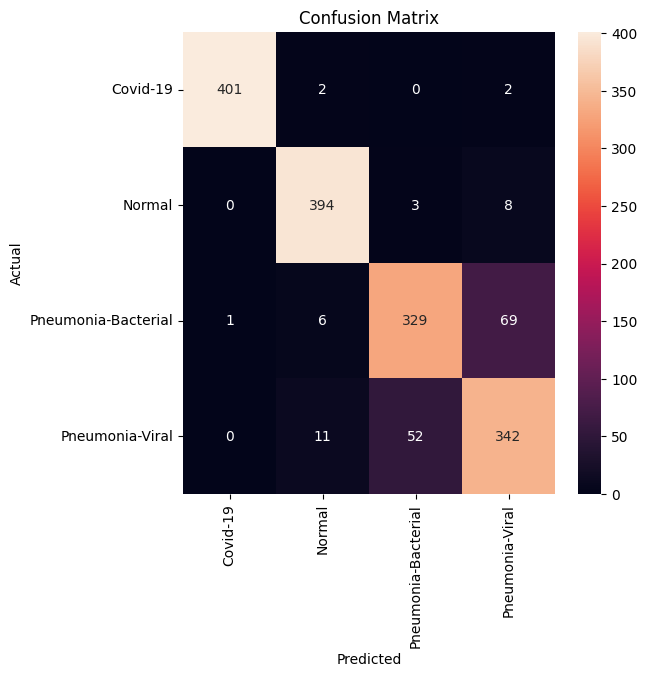

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

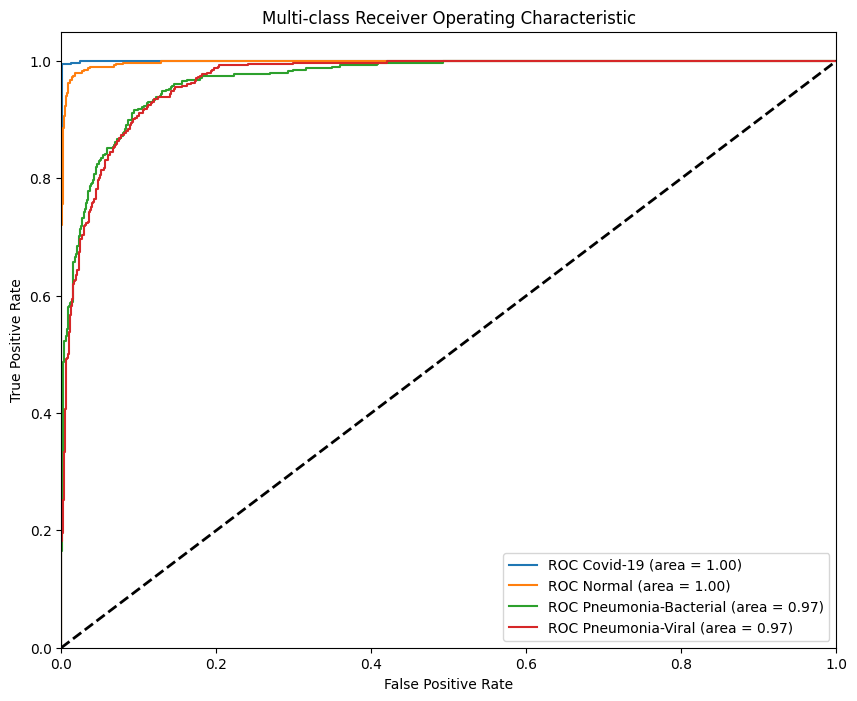

In [16]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Get probability scores for the test set
model.eval()
all_probs = []
all_labels_roc = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = torch.softmax(model(images), dim=1)
        all_probs.append(outputs.cpu().numpy())
        all_labels_roc.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_labels_roc = np.concatenate(all_labels_roc)

# 2. Binarize labels for multi-class ROC calculation
n_classes = len(class_names)
y_test_bin = label_binarize(all_labels_roc, classes=range(n_classes))

# 3. Compute ROC and AUC for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC {class_names[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [19]:
import torch
import torch.nn as nn
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [26]:
import torch.nn.functional as F

def new_forward(self, x):
    features = self.features(x)
    
    # ❌ original: F.relu(features, inplace=True)
    out = F.relu(features, inplace=False)   # ✅ FIX
    
    out = F.adaptive_avg_pool2d(out, (1, 1))
    out = torch.flatten(out, 1)
    out = self.classifier(out)
    return out

# Apply patch
model.forward = new_forward.__get__(model, model.__class__)

In [20]:
def replace_relu(module):
    for name, child in module.named_children():
        if isinstance(child, nn.ReLU):
            setattr(module, name, nn.ReLU(inplace=False))
        else:
            replace_relu(child)

In [28]:
model.eval()
replace_relu(model)

In [22]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.clone()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].clone()

    def generate(self, input_tensor, class_idx):
        output = self.model(input_tensor)

        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1)

        cam = cam.squeeze().cpu().detach().numpy()
        cam = np.maximum(cam, 0)

        cam = cv2.resize(cam, (256, 256))
        cam = cam / cam.max()  # normalize

        return cam

In [29]:
target_layer = model.features.denseblock4
grad_cam = GradCAM(model, target_layer)

In [30]:
images, labels = next(iter(test_loader))
sample_img = images[0:1].to(device)

mask = grad_cam.generate(sample_img, labels[0].item())

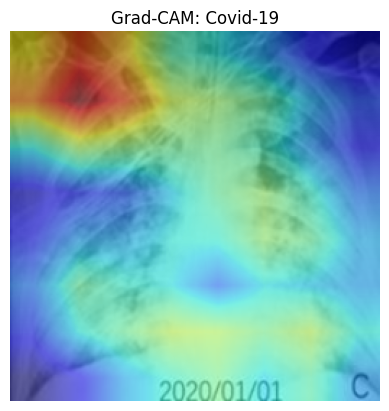

In [31]:
img_np = images[0].permute(1, 2, 0).cpu().numpy()

# Unnormalize (ImageNet stats)
img_np = (img_np * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])

plt.imshow(np.clip(img_np, 0, 1))
plt.imshow(mask, cmap='jet', alpha=0.5)
plt.title(f"Grad-CAM: {class_names[labels[0]]}")
plt.axis('off')
plt.show()